In [1]:
# 🍔 Food Delivery Analytics & Delivery Time Prediction

## 1. Project Overview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
## 2. Data Loading & Initial Exploration

In [3]:
df = pd.read_csv("../data/food_orders.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 38964
Columns: 22


In [4]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [5]:
df.tail()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
38959,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,21:45,...,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,33,16.600272,Average
38960,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,...,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,1.489846,Average
38961,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,...,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,4.657195,Fast
38962,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,...,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,6.232393,Average
38963,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10,...,Medium,2,Snack,scooter,1.0,No,Metropolitian,36,12.074396,Slow


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38964 entries, 0 to 38963
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           38964 non-null  object 
 1   Delivery_person_ID           38964 non-null  object 
 2   Delivery_person_Age          37945 non-null  float64
 3   Delivery_person_Ratings      37909 non-null  float64
 4   Restaurant_latitude          38964 non-null  float64
 5   Restaurant_longitude         38964 non-null  float64
 6   Delivery_location_latitude   38964 non-null  float64
 7   Delivery_location_longitude  38964 non-null  float64
 8   Order_Date                   38964 non-null  object 
 9   Time_Orderd                  38129 non-null  object 
 10  Time_Order_picked            38964 non-null  object 
 11  Weather_conditions           38964 non-null  object 
 12  Road_traffic_density         38964 non-null  object 
 13  Vehicle_conditio

In [7]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min),distance_km
count,37945.000000,37909.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000
mean,29.607089,4.631879,18.915583,76.914536,18.979545,76.978498,0.995534,0.749589,26.581511,9.765092
std,5.763202,0.317006,5.460635,3.498179,5.462504,3.498357,0.817312,0.572172,9.339546,5.605705
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.066047,73.938972,0.000000,0.000000,19.000000,4.658009
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.663067,1.000000,1.000000,26.000000,9.219906
75%,35.000000,4.900000,22.751234,78.368855,22.820072,78.405467,2.000000,1.000000,33.000000,13.681590
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,20.969489


In [8]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1019
Delivery_person_Ratings        1055
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                     835
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
distance_km                       0
delivery_speed                    0
dtype: int64

In [9]:
(df.isnull().sum() / len(df) * 100).round(2)

ID                             0.00
Delivery_person_ID             0.00
Delivery_person_Age            2.62
Delivery_person_Ratings        2.71
Restaurant_latitude            0.00
Restaurant_longitude           0.00
Delivery_location_latitude     0.00
Delivery_location_longitude    0.00
Order_Date                     0.00
Time_Orderd                    2.14
Time_Order_picked              0.00
Weather_conditions             0.00
Road_traffic_density           0.00
Vehicle_condition              0.00
Type_of_order                  0.00
Type_of_vehicle                0.00
multiple_deliveries            0.00
Festival                       0.00
City                           0.00
Time_taken (min)               0.00
distance_km                    0.00
delivery_speed                 0.00
dtype: float64

In [10]:
df_raw = df.copy()

print("Backup created.")
print("Original rows:", len(df_raw))

Backup created.
Original rows: 38964


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing[missing["Missing Values"] > 0]

,Missing Values,Missing %
Delivery_person_Age,1019,2.62
Delivery_person_Ratings,1055,2.71
Time_Orderd,835,2.14


In [13]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
distance_km                    float64
delivery_speed                  object
dtype: object

In [14]:
categorical_columns = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Weather_conditions:
Weather_conditions
Fog           6660
Stormy        6572
Cloudy        6563
Sandstorms    6489
Windy         6436
Sunny         6244
Name: count, dtype: int64

Road_traffic_density:
Road_traffic_density
Low       13139
Jam       12414
Medium     9556
High       3855
Name: count, dtype: int64

Type_of_order:
Type_of_order
Snack     9815
Meal      9774
Drinks    9751
Buffet    9624
Name: count, dtype: int64

Type_of_vehicle:
Type_of_vehicle
motorcycle          22942
scooter             12926
electric_scooter     3096
Name: count, dtype: int64

Festival:
Festival
No     38180
Yes      784
Name: count, dtype: int64

City:
City
Metropolitian    30036
Urban             8782
Semi-Urban         146
Name: count, dtype: int64


In [16]:
df_clean = df.copy()

In [17]:
df_clean.shape

(38964, 22)

In [18]:
df_clean["Time_taken (min)"].describe()

count    38964.000000
mean        26.581511
std          9.339546
min         10.000000
25%         19.000000
50%         26.000000
75%         33.000000
max         54.000000
Name: Time_taken (min), dtype: float64

In [19]:
avg_delivery_time = df_clean["Time_taken (min)"].mean()
median_delivery_time = df_clean["Time_taken (min)"].median()
fastest_delivery = df_clean["Time_taken (min)"].min()
slowest_delivery = df_clean["Time_taken (min)"].max()

print(f"Average delivery time: {avg_delivery_time:.2f} minutes")
print(f"Median delivery time: {median_delivery_time:.2f} minutes")
print(f"Fastest delivery: {fastest_delivery:.2f} minutes")
print(f"Slowest delivery: {slowest_delivery:.2f} minutes")

Average delivery time: 26.58 minutes
Median delivery time: 26.00 minutes
Fastest delivery: 10.00 minutes
Slowest delivery: 54.00 minutes


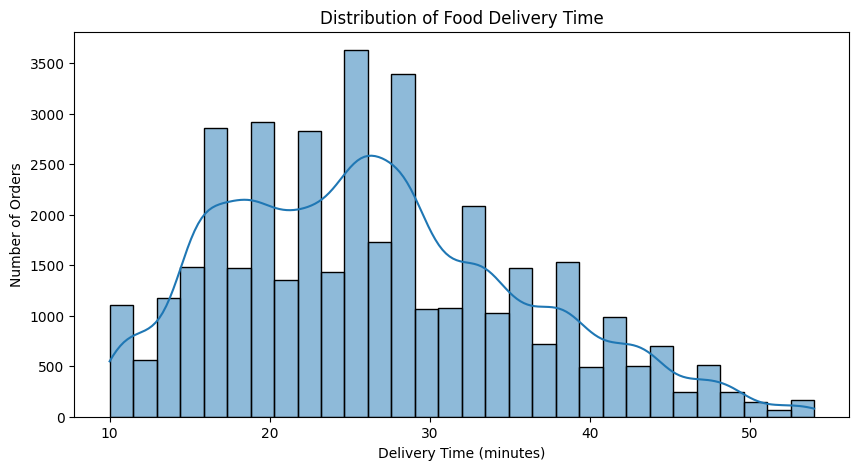

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Time_taken (min)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Food Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")

plt.show()

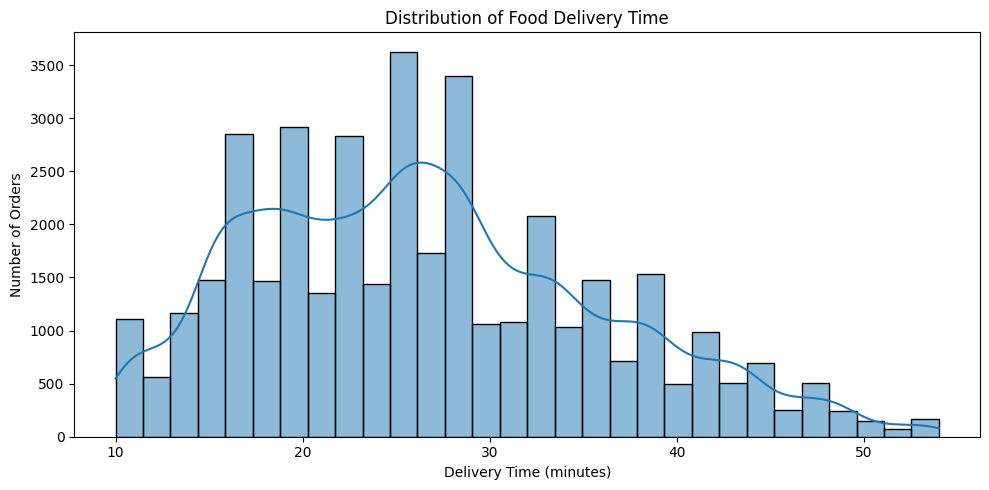

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Time_taken (min)"],
    bins=30,
    kde=True
)

plt.title("Distribution of Food Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("../images/delivery_time_distribution.png", dpi=300)

plt.show()

In [22]:
traffic_analysis = (
    df_clean.groupby("Road_traffic_density")["Time_taken (min)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

traffic_analysis

,count,mean,median
Road_traffic_density,,,
Low,13139,21.496461,21.0
Medium,9556,26.925701,27.0
High,3855,27.413489,27.0
Jam,12414,31.440229,31.0


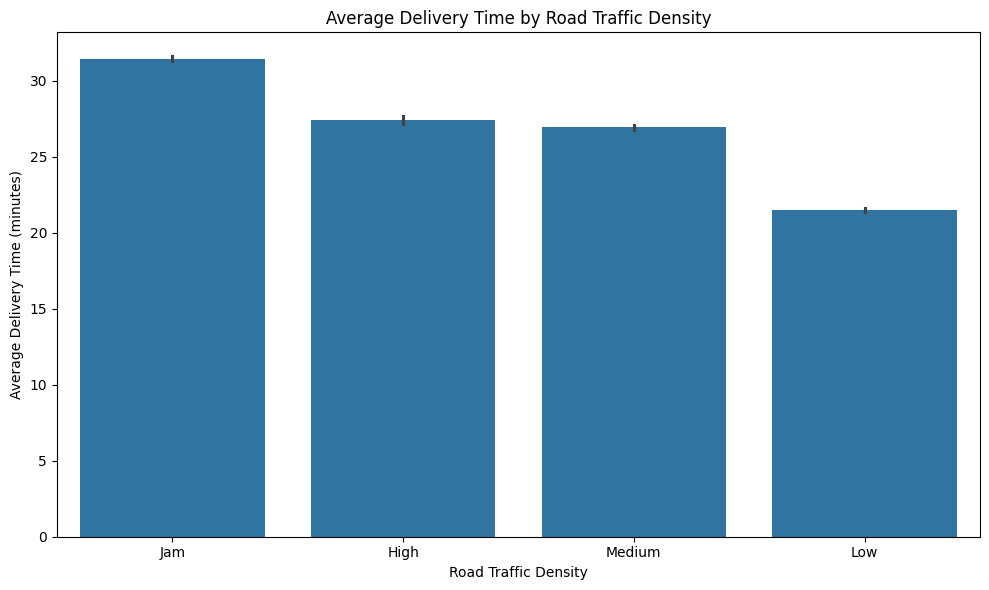

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="Road_traffic_density",
    y="Time_taken (min)",
    estimator="mean"
)

plt.title("Average Delivery Time by Road Traffic Density")
plt.xlabel("Road Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")

plt.tight_layout()
plt.savefig("../images/traffic_vs_delivery_time.png", dpi=300)

plt.show()

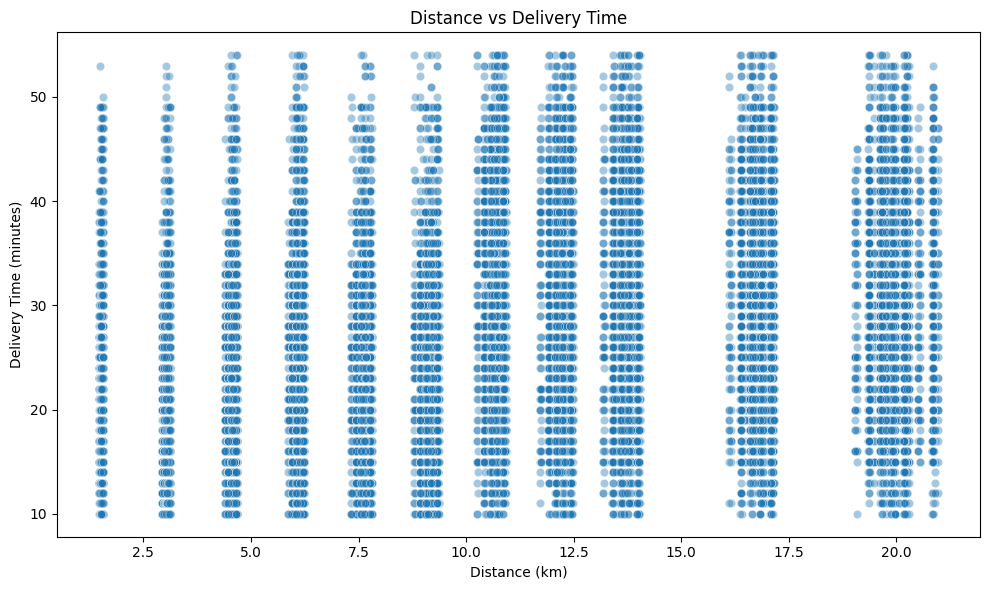

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="distance_km",
    y="Time_taken (min)",
    alpha=0.4
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.savefig("../images/distance_vs_delivery_time.png", dpi=300)

plt.show()

In [25]:
correlation = df_clean["distance_km"].corr(
    df_clean["Time_taken (min)"]
)

print(f"Correlation between distance and delivery time: {correlation:.3f}")

Correlation between distance and delivery time: 0.322


In [26]:
weather_analysis = (
    df_clean.groupby("Weather_conditions")["Time_taken (min)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

weather_analysis

,count,mean,median
Weather_conditions,,,
Sunny,6244,22.196669,21.0
Sandstorms,6489,26.121590,26.0
Stormy,6572,26.146835,26.0
Windy,6436,26.388440,26.0
Cloudy,6563,29.154655,29.0
Fog,6660,29.220420,29.0


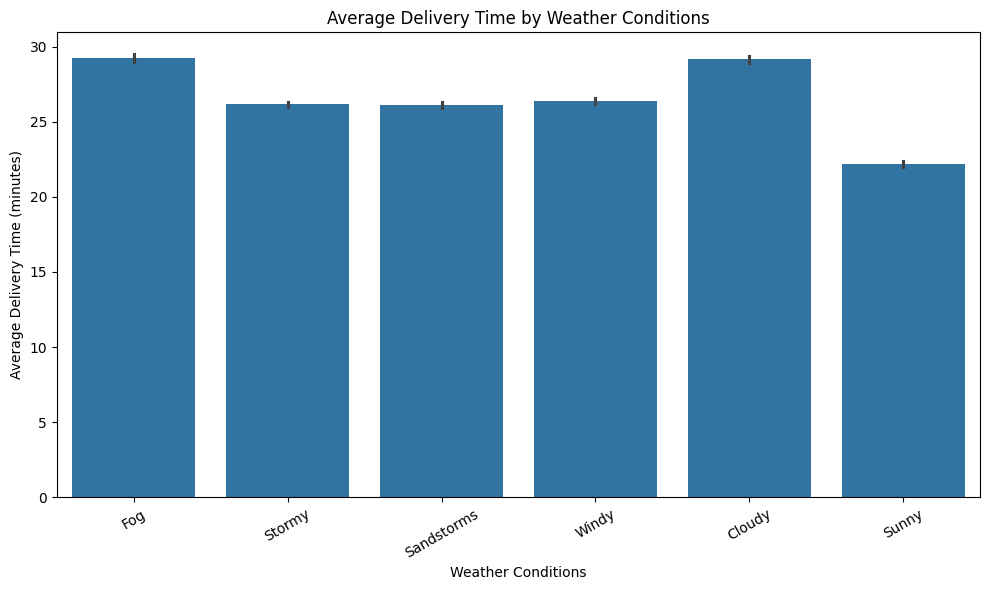

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="Weather_conditions",
    y="Time_taken (min)",
    estimator="mean"
)

plt.title("Average Delivery Time by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../images/weather_vs_delivery_time.png", dpi=300)

plt.show()

In [28]:
vehicle_analysis = (
    df_clean.groupby("Type_of_vehicle")["Time_taken (min)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

vehicle_analysis

,count,mean,median
Type_of_vehicle,,,
electric_scooter,3096,24.560724,24.0
scooter,12926,24.805818,25.0
motorcycle,22942,27.854677,27.0


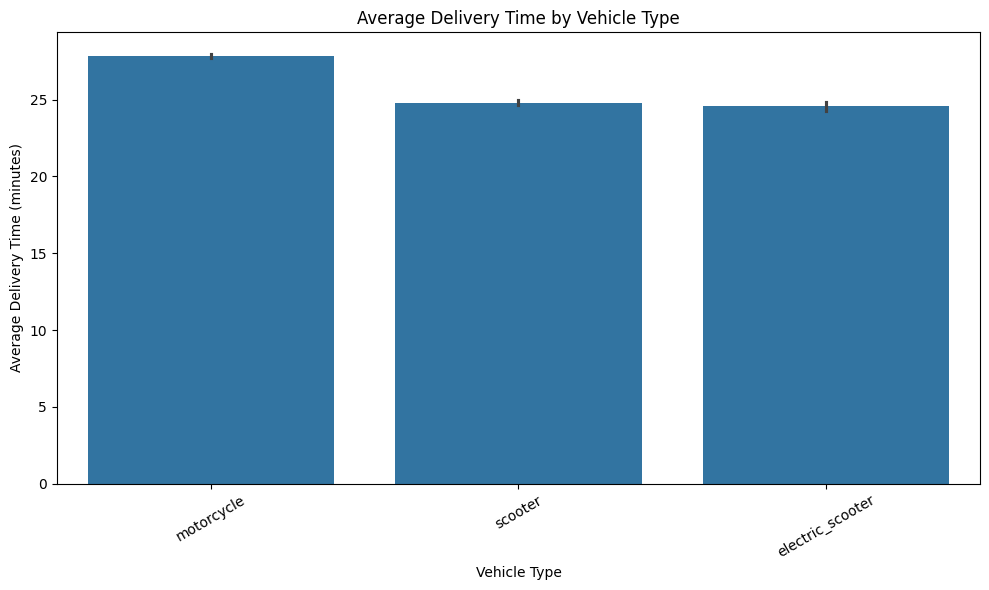

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="Type_of_vehicle",
    y="Time_taken (min)",
    estimator="mean"
)

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../images/vehicle_vs_delivery_time.png", dpi=300)

plt.show()

In [30]:
city_analysis = (
    df_clean.groupby("City")["Time_taken (min)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

city_analysis

,count,mean,median
City,,,
Urban,8782,23.243339,22.0
Metropolitian,30036,27.445199,27.0
Semi-Urban,146,49.691781,49.0


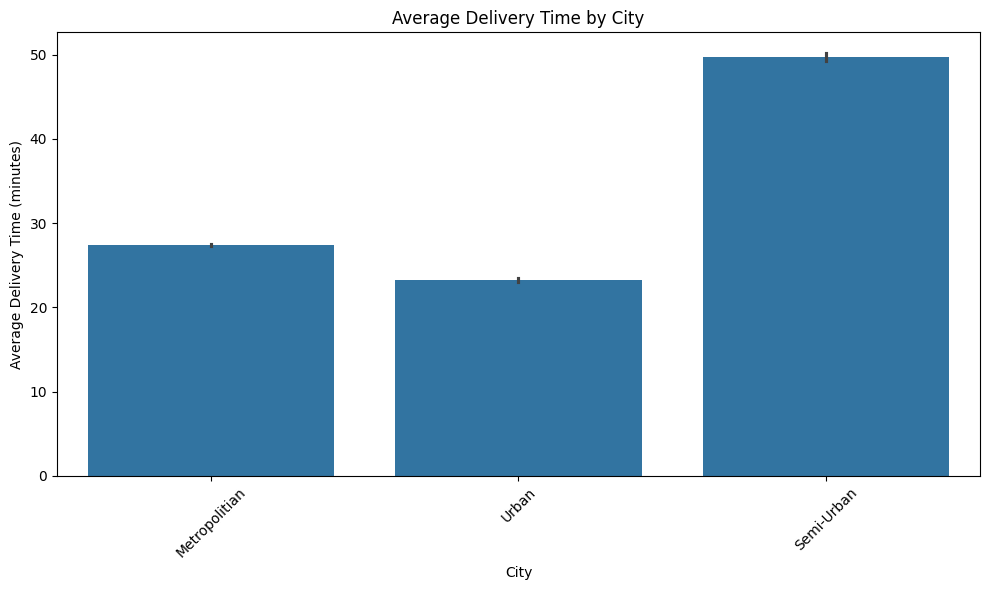

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="City",
    y="Time_taken (min)",
    estimator="mean"
)

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/city_vs_delivery_time.png", dpi=300)

plt.show()

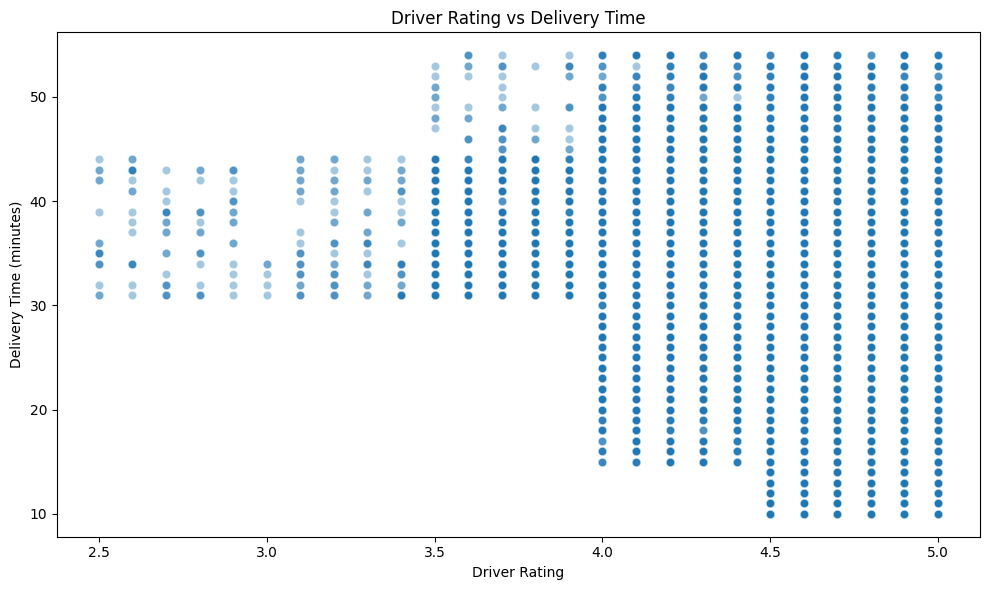

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Delivery_person_Ratings",
    y="Time_taken (min)",
    alpha=0.4
)

plt.title("Driver Rating vs Delivery Time")
plt.xlabel("Driver Rating")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.savefig("../images/rating_vs_delivery_time.png", dpi=300)

plt.show()

In [33]:
rating_correlation = df_clean["Delivery_person_Ratings"].corr(
    df_clean["Time_taken (min)"]
)

print(f"Correlation between driver rating and delivery time: {rating_correlation:.3f}")

Correlation between driver rating and delivery time: -0.362


In [34]:
df_clean.select_dtypes(include="number").columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Time_taken (min)', 'distance_km'],
      dtype='object')

In [35]:
numeric_df = df_clean.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min),distance_km
Delivery_person_Age,1.000000,-0.115660,0.004074,0.010832,0.004058,0.010808,-0.001223,0.115324,0.296839,-0.002351
Delivery_person_Ratings,-0.115660,1.000000,-0.004195,0.003641,-0.004923,0.002502,0.043946,-0.123986,-0.361766,-0.108290
Restaurant_latitude,0.004074,-0.004195,1.000000,0.002094,0.999977,0.002593,0.002661,0.009895,0.012852,0.019635
Restaurant_longitude,0.010832,0.003641,0.002094,1.000000,0.002091,0.999945,0.003555,0.008949,0.006942,-0.001048
Delivery_location_latitude,0.004058,-0.004923,0.999977,0.002091,1.000000,0.002660,0.002716,0.010723,0.015012,0.026359
Delivery_location_longitude,0.010808,0.002502,0.002593,0.999945,0.002660,1.000000,0.003641,0.010246,0.010321,0.009460
Vehicle_condition,-0.001223,0.043946,0.002661,0.003555,0.002716,0.003641,1.000000,-0.102991,-0.242171,0.008195
multiple_deliveries,0.115324,-0.123986,0.009895,0.008949,0.010723,0.010246,-0.102991,1.000000,0.383138,0.123174
Time_taken (min),0.296839,-0.361766,0.012852,0.006942,0.015012,0.010321,-0.242171,0.383138,1.000000,0.321532
distance_km,-0.002351,-0.108290,0.019635,-0.001048,0.026359,0.009460,0.008195,0.123174,0.321532,1.000000


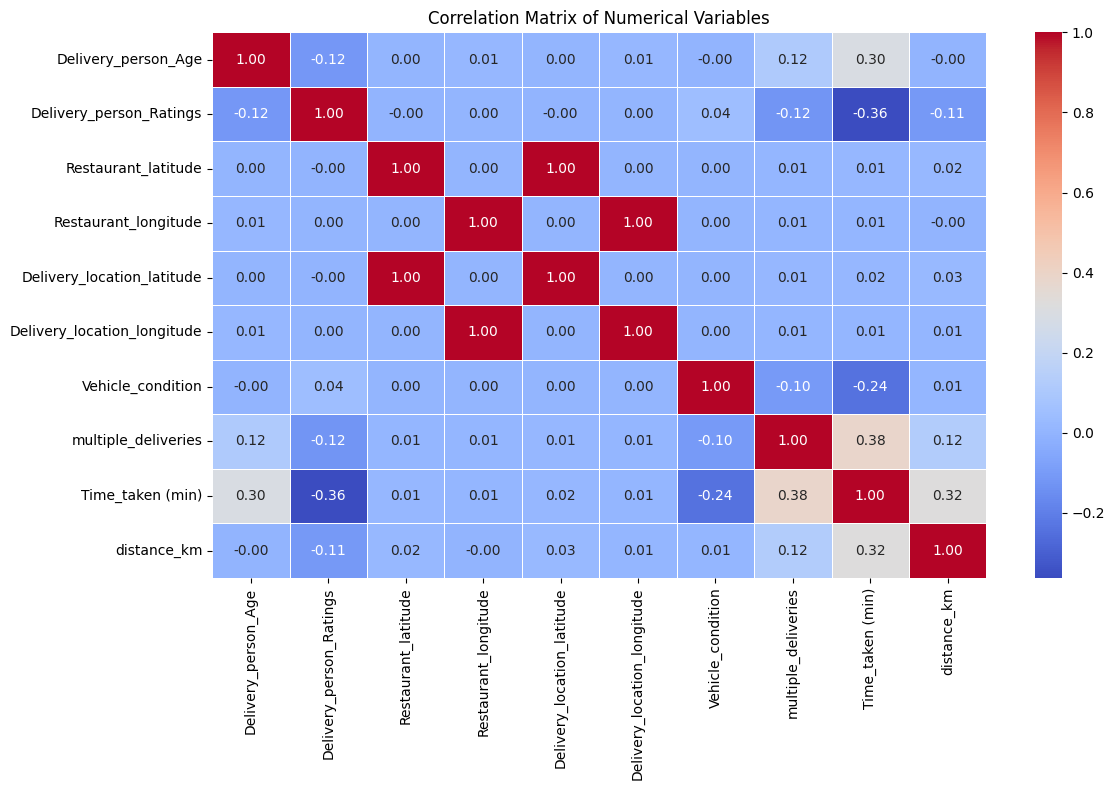

In [36]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

plt.savefig("../images/correlation_heatmap.png", dpi=300)

plt.show()

In [37]:
delivery_correlations = (
    correlation_matrix["Time_taken (min)"]
    .sort_values(ascending=False)
)

delivery_correlations

Time_taken (min)               1.000000
multiple_deliveries            0.383138
distance_km                    0.321532
Delivery_person_Age            0.296839
Delivery_location_latitude     0.015012
Restaurant_latitude            0.012852
Delivery_location_longitude    0.010321
Restaurant_longitude           0.006942
Vehicle_condition             -0.242171
Delivery_person_Ratings       -0.361766
Name: Time_taken (min), dtype: float64

In [38]:
df_clean.shape

(38964, 22)

In [39]:
df_clean.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [40]:
df_clean.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
distance_km                    float64
delivery_speed                  object
dtype: object

In [41]:
delivery_correlations

Time_taken (min)               1.000000
multiple_deliveries            0.383138
distance_km                    0.321532
Delivery_person_Age            0.296839
Delivery_location_latitude     0.015012
Restaurant_latitude            0.012852
Delivery_location_longitude    0.010321
Restaurant_longitude           0.006942
Vehicle_condition             -0.242171
Delivery_person_Ratings       -0.361766
Name: Time_taken (min), dtype: float64

In [42]:
features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "distance_km",
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

target = "Time_taken (min)"

X = df_clean[features]
y = df_clean[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (38964, 11)
Target: (38964,)


In [43]:
X.isnull().sum()

Delivery_person_Age        1019
Delivery_person_Ratings    1055
Vehicle_condition             0
multiple_deliveries           0
distance_km                   0
Weather_conditions            0
Road_traffic_density          0
Type_of_order                 0
Type_of_vehicle               0
Festival                      0
City                          0
dtype: int64

In [44]:
y.isnull().sum()

np.int64(0)

In [47]:
numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "distance_km"
]

categorical_features = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

In [46]:
X.isnull().sum()

Delivery_person_Age        1019
Delivery_person_Ratings    1055
Vehicle_condition             0
multiple_deliveries           0
distance_km                   0
Weather_conditions            0
Road_traffic_density          0
Type_of_order                 0
Type_of_vehicle               0
Festival                      0
City                          0
dtype: int64

In [48]:
print("Missing delivery times:", df_clean["Time_taken (min)"].isnull().sum())

Missing delivery times: 0


In [50]:
df_ml = df_clean.copy()

df_ml["Delivery_person_Age"] = df_ml["Delivery_person_Age"].fillna(
    df_ml["Delivery_person_Age"].median()
)

df_ml["Delivery_person_Ratings"] = df_ml["Delivery_person_Ratings"].fillna(
    df_ml["Delivery_person_Ratings"].median()
)

In [51]:
df_ml[["Delivery_person_Age", "Delivery_person_Ratings"]].isnull().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
dtype: int64

In [52]:
X = df_ml[features]
y = df_ml[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (38964, 11)
y shape: (38964,)


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 31171
Testing rows: 7793


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [56]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Random Forest model created!


In [57]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Complete ML pipeline created!")

Complete ML pipeline created!


In [58]:
model_pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [59]:
y_pred = model_pipeline.predict(X_test)

print("Predictions generated!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated!
First 10 predictions:
[27.6  23.72 40.29 24.   24.51 30.79 21.86 42.72 16.81 22.37]


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.3f}")

NameError: name 'y_test' is not defined

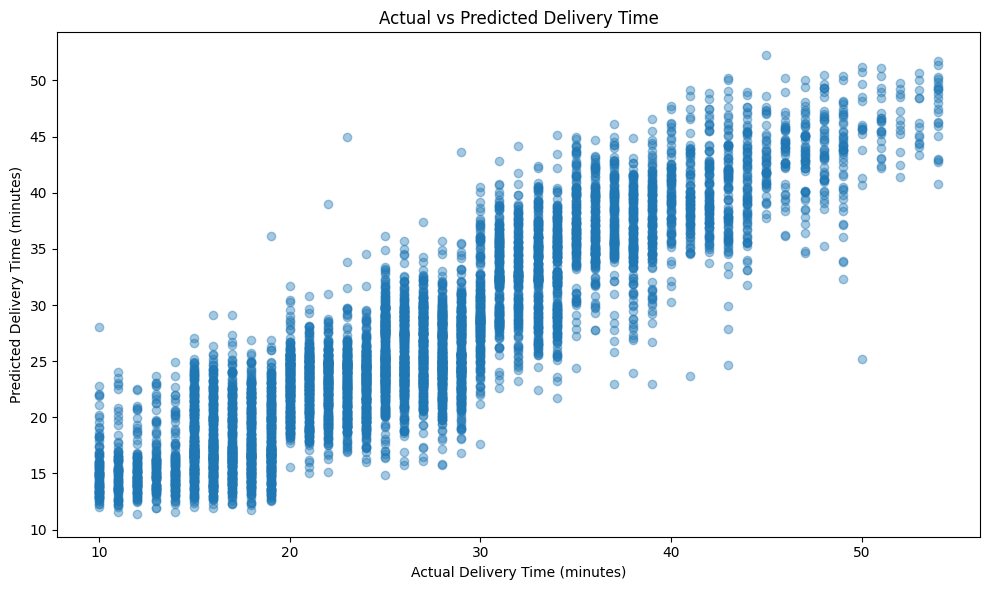

In [61]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.tight_layout()
plt.savefig("../images/actual_vs_predicted.png", dpi=300)

plt.show()

In [62]:
print("Model Performance")
print("------------------")
print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.3f}")

Model Performance
------------------
MAE  : 3.12 minutes
RMSE : 3.93 minutes
R²   : 0.818


In [63]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = model_pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
1,num__Delivery_person_Ratings,0.214971
4,num__distance_km,0.146839
13,cat__Road_traffic_density_Low,0.112910
3,num__multiple_deliveries,0.109401
0,num__Delivery_person_Age,0.101413
9,cat__Weather_conditions_Sunny,0.070288
2,num__Vehicle_condition,0.070120
5,cat__Weather_conditions_Cloudy,0.045565
6,cat__Weather_conditions_Fog,0.045440
14,cat__Road_traffic_density_Medium,0.017187


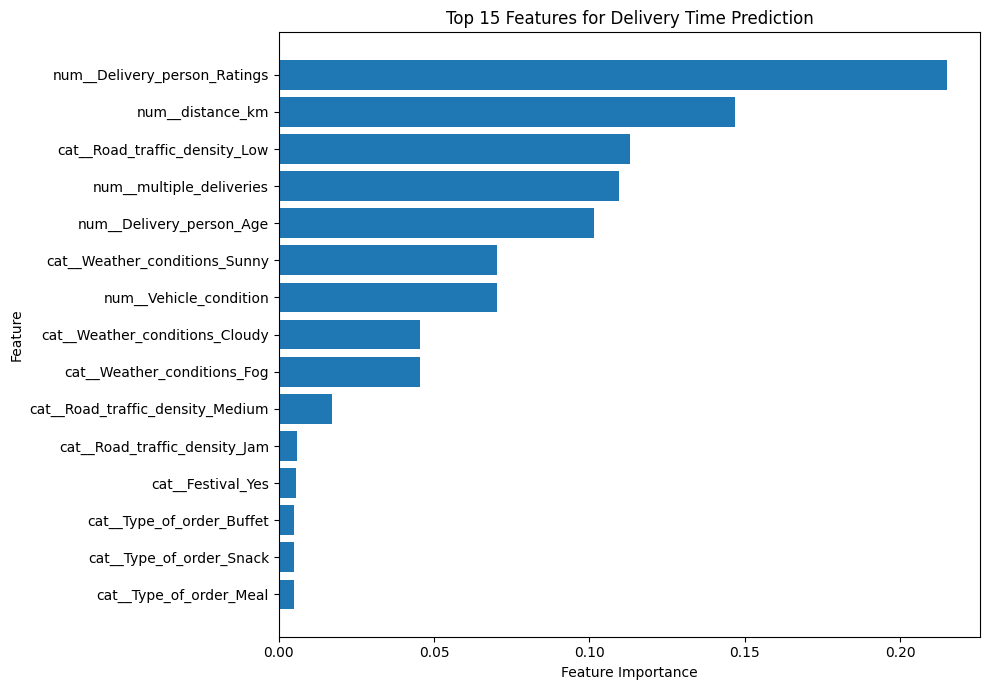

In [64]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features for Delivery Time Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=300)

plt.show()

In [65]:
model_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

model_summary

,Metric,Value
0,MAE,3.117092
1,RMSE,3.931481
2,R²,0.818385
